In [1]:
import subprocess

libs = ['folium', 'plotly', 'ipywidgets']
for lib in libs:
    subprocess.run(['pip', 'install', lib, '--quiet'], capture_output=True)
    print(f"{lib:<15} ✓")

print("\nAll dashboard libraries ready")

folium          ✓
plotly          ✓
ipywidgets      ✓

All dashboard libraries ready


In [2]:
import pandas as pd
import numpy as np
import folium
import plotly.graph_objects as go
import plotly.express as px
from ipywidgets import interact, widgets, Output
import warnings
warnings.filterwarnings('ignore')

# ── Load ──────────────────────────────────────────────────
orders      = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
customers   = pd.read_csv('olist_customers_dataset.csv')
products    = pd.read_csv('olist_products_dataset.csv')
translation = pd.read_csv('product_category_name_translation.csv')
geo         = pd.read_csv('olist_geolocation_dataset.csv')

orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp'])
delivered = orders[orders['order_status'] == 'delivered'].copy()
products  = products.merge(translation, on='product_category_name', how='left')

# ── Aggregate items ───────────────────────────────────────
item_agg = order_items.groupby('order_id').agg(
    revenue    = ('price',         'sum'),
    freight    = ('freight_value', 'sum'),
    product_id = ('product_id',    'first')
).reset_index()

# ── Master join ───────────────────────────────────────────
merged = (delivered
    .merge(item_agg,  on='order_id')
    .merge(customers, on='customer_id')
    .merge(products[['product_id',
                     'product_category_name_english']],
           on='product_id', how='left')
)
merged['order_month'] = merged['order_purchase_timestamp'].dt.to_period('M')
merged['year']        = merged['order_purchase_timestamp'].dt.year

# ── State centroid from geolocation ──────────────────────
state_geo = (geo
    .groupby('geolocation_state')
    .agg(lat=('geolocation_lat','mean'),
         lng=('geolocation_lng','mean'))
    .reset_index()
    .rename(columns={'geolocation_state':'customer_state'})
)

print("All data rebuilt ✓")
print(f"Orders : {len(merged):,}")
print(f"States : {merged['customer_state'].nunique()}")
print(f"Cats   : {merged['product_category_name_english'].nunique()}")

All data rebuilt ✓
Orders : 96,478
States : 27
Cats   : 71


In [3]:
# Revenue + order count per state
state_revenue = (merged
    .groupby('customer_state')
    .agg(
        total_revenue  = ('revenue',  'sum'),
        total_orders   = ('order_id', 'nunique'),
        avg_order_val  = ('revenue',  'mean'),
        unique_cats    = ('product_category_name_english', 'nunique')
    )
    .reset_index()
)
state_revenue['total_revenue'] = state_revenue['total_revenue'].round(2)
state_revenue['avg_order_val'] = state_revenue['avg_order_val'].round(2)
state_revenue['revenue_share'] = (
    state_revenue['total_revenue'] /
    state_revenue['total_revenue'].sum() * 100
).round(2)

# Merge with geo centroids
state_map_df = state_revenue.merge(state_geo, on='customer_state', how='left')

print("State map dataset ready ✓")
print(state_map_df.sort_values('total_revenue', ascending=False)
      [['customer_state','total_revenue','revenue_share','lat','lng']
       ].to_string(index=False))

State map dataset ready ✓
customer_state  total_revenue  revenue_share        lat        lng
            SP     5067633.16          38.33 -23.155308 -47.084074
            RJ     1759651.13          13.31 -22.743477 -43.155540
            MG     1552481.83          11.74 -19.864647 -44.421615
            RS      728897.47           5.51 -29.679191 -52.032652
            PR      666063.51           5.04 -24.793607 -50.879662
            SC      507012.13           3.83 -27.222486 -49.617937
            BA      493584.14           3.73 -13.049361 -39.560649
            DF      296498.41           2.24 -15.810885 -47.969630
            GO      282836.70           2.14 -16.577645 -49.334195
            ES      268643.45           2.03 -20.105145 -40.503183
            PE      251889.49           1.91  -8.179098 -35.758866
            CE      219757.38           1.66  -4.363151 -39.004140
            PA      174470.59           1.32  -2.631213 -49.485862
            MT      152191.62       

In [4]:
# Base map centred on Brazil
m = folium.Map(
    location  = [-15.0, -51.0],
    zoom_start= 4,
    tiles     = 'CartoDB positron'
)

# Scale circle radius to revenue
max_rev    = state_map_df['total_revenue'].max()
min_radius = 8
max_radius = 55

for _, row in state_map_df.dropna(subset=['lat','lng']).iterrows():

    # Radius scaled by revenue share
    radius = (min_radius +
              (row['total_revenue'] / max_rev) *
              (max_radius - min_radius))

    # Colour: top 5 states green, next 5 orange, rest coral
    rank = state_map_df['total_revenue'].rank(ascending=False)[_]
    color = ('#2ecc71' if rank <= 5  else
             '#f39c12' if rank <= 10 else '#e74c3c')

    # Popup card
    popup_html = f"""
    <div style="font-family:Arial; width:200px">
        <h4 style="margin:0;color:#2c3e50">{row['customer_state']}</h4>
        <hr style="margin:4px 0">
        <b>Revenue :</b> BRL {row['total_revenue']:,.0f}<br>
        <b>Share   :</b> {row['revenue_share']:.1f}% of total<br>
        <b>Orders  :</b> {row['total_orders']:,}<br>
        <b>Avg Order:</b> BRL {row['avg_order_val']:.2f}<br>
        <b>Categories:</b> {row['unique_cats']}
    </div>
    """

    folium.CircleMarker(
        location  = [row['lat'], row['lng']],
        radius    = radius,
        color     = color,
        fill      = True,
        fill_color= color,
        fill_opacity = 0.7,
        popup     = folium.Popup(popup_html, max_width=220),
        tooltip   = (f"{row['customer_state']}  |  "
                     f"BRL {row['total_revenue']:,.0f}  |  "
                     f"{row['revenue_share']:.1f}%")
    ).add_to(m)

    # State label
    folium.Marker(
        location = [row['lat'], row['lng']],
        icon     = folium.DivIcon(
            html=(f'<div style="font-size:8px;font-weight:bold;'
                  f'color:#2c3e50;text-align:center">'
                  f'{row["customer_state"]}</div>'),
            icon_size   = (30, 12),
            icon_anchor = (15, 6)
        )
    ).add_to(m)

# Legend
legend_html = """
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
            background:white;padding:12px;border-radius:8px;
            box-shadow:2px 2px 6px rgba(0,0,0,0.3);font-family:Arial">
    <b>Revenue Tier</b><br>
    <span style="color:#2ecc71">●</span> Top 5 states<br>
    <span style="color:#f39c12">●</span> States 6–10<br>
    <span style="color:#e74c3c">●</span> Remaining states<br>
    <small>Circle size = revenue share<br>Click circle for details</small>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Save and display
m.save('olist_sales_map.html')
print("olist_sales_map.html saved ✓")
print("Open this file in your browser for full interactivity")
print("Or run the next cell to display inline in Jupyter")
m

olist_sales_map.html saved ✓
Open this file in your browser for full interactivity
Or run the next cell to display inline in Jupyter


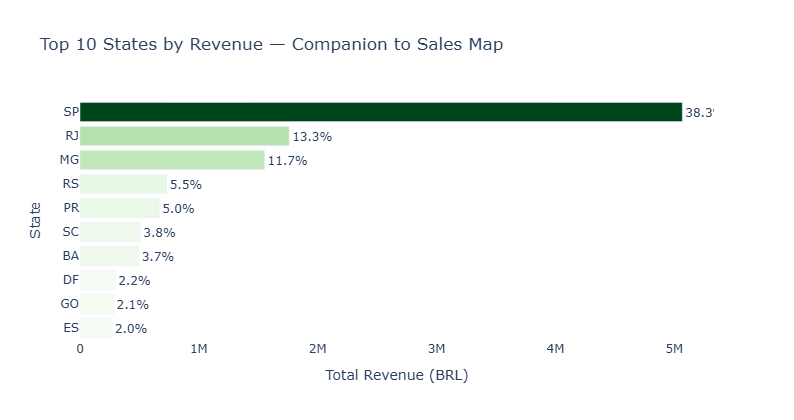


SP alone accounts for 38.3% of total revenue


In [5]:
top_states = state_map_df.nlargest(10, 'total_revenue')

fig = px.bar(
    top_states.sort_values('total_revenue'),
    x          = 'total_revenue',
    y          = 'customer_state',
    orientation= 'h',
    color      = 'revenue_share',
    color_continuous_scale = 'Greens',
    text       = top_states.sort_values('total_revenue')
                           ['revenue_share'].apply(lambda x: f'{x:.1f}%'),
    labels     = {'total_revenue'  : 'Total Revenue (BRL)',
                  'customer_state' : 'State',
                  'revenue_share'  : 'Revenue Share %'},
    title      = 'Top 10 States by Revenue — Companion to Sales Map'
)

fig.update_layout(
    height          = 420,
    plot_bgcolor    = 'white',
    paper_bgcolor   = 'white',
    coloraxis_showscale = False
)
fig.update_traces(textposition='outside')
fig.show()

print(f"\nSP alone accounts for "
      f"{state_map_df[state_map_df['customer_state']=='SP']['revenue_share'].values[0]:.1f}%"
      f" of total revenue")

In [6]:
# Top 12 categories + Other bucket
cat_rev = (merged
    .groupby('product_category_name_english')['revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
cat_rev.columns = ['category', 'revenue']
cat_rev['revenue'] = cat_rev['revenue'].round(2)

top12     = cat_rev.head(12).copy()
other_rev = cat_rev.iloc[12:]['revenue'].sum()
other_row = pd.DataFrame([{'category': 'All Others',
                            'revenue' : round(other_rev, 2)}])
waterfall_df = pd.concat([top12, other_row], ignore_index=True)

# Running total for waterfall
waterfall_df['running_total'] = waterfall_df['revenue'].cumsum()
waterfall_df['pct_share']     = (waterfall_df['revenue'] /
                                  waterfall_df['revenue'].sum() * 100
                                  ).round(2)

print("Waterfall data ready ✓")
print(waterfall_df[['category','revenue','running_total','pct_share']
                   ].to_string(index=False))

Waterfall data ready ✓
             category    revenue  running_total  pct_share
        health_beauty 1232074.12     1232074.12       9.44
        watches_gifts 1163585.35     2395659.47       8.92
       bed_bath_table 1022202.47     3417861.94       7.84
       sports_leisure  956122.87     4373984.81       7.33
computers_accessories  887181.15     5261165.96       6.80
      furniture_decor  715568.48     5976734.44       5.49
           housewares  617564.75     6594299.19       4.73
           cool_stuff  611226.51     7205525.70       4.69
                 auto  578997.00     7784522.70       4.44
         garden_tools  470924.13     8255446.83       3.61
                 toys  470696.59     8726143.42       3.61
                 baby  399829.20     9125972.62       3.06
           All Others 3919719.38    13045692.00      30.05


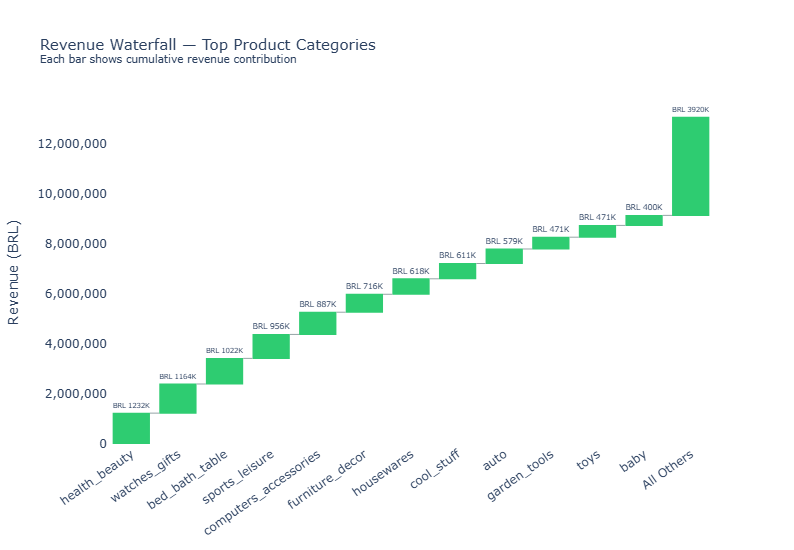


Total revenue (top 12 + other) : BRL 13,045,692.00
Top 3 categories combined      : BRL 3,417,861.94  (26.2% of total)


In [7]:
# Waterfall measure type — all 'relative' except final 'total'
measures = ['relative'] * len(waterfall_df)

# Colour each bar by revenue size
bar_colors = [
    '#2ecc71' if i < 3   else
    '#27ae60' if i < 6   else
    '#f39c12' if i < 10  else
    '#e74c3c'
    for i in range(len(waterfall_df))
]

fig = go.Figure(go.Waterfall(
    name        = 'Revenue',
    orientation = 'v',
    measure     = measures,
    x           = waterfall_df['category'],
    y           = waterfall_df['revenue'],
    text        = waterfall_df['revenue'].apply(
                    lambda v: f'BRL {v/1e3:.0f}K'),
    textposition= 'outside',
    connector   = {'line': {'color': '#95a5a6', 'width': 1}},
    decreasing  = {'marker': {'color': '#e74c3c'}},
    increasing  = {'marker': {'color': '#2ecc71'}},
    totals      = {'marker': {'color': '#3498db'}}
))

fig.update_layout(
    title      = dict(
        text  = 'Revenue Waterfall — Top Product Categories<br>'
                '<sup>Each bar shows cumulative revenue contribution</sup>',
        font  = dict(size=15)
    ),
    xaxis      = dict(tickangle=-35),
    yaxis      = dict(
        title = 'Revenue (BRL)',
        tickformat = ',.0f'
    ),
    height     = 550,
    plot_bgcolor  = 'white',
    paper_bgcolor = 'white',
    showlegend = False
)

fig.show()

total = waterfall_df['revenue'].sum()
top3  = waterfall_df.head(3)['revenue'].sum()
print(f"\nTotal revenue (top 12 + other) : BRL {total:,.2f}")
print(f"Top 3 categories combined      : BRL {top3:,.2f}"
      f"  ({top3/total*100:.1f}% of total)")

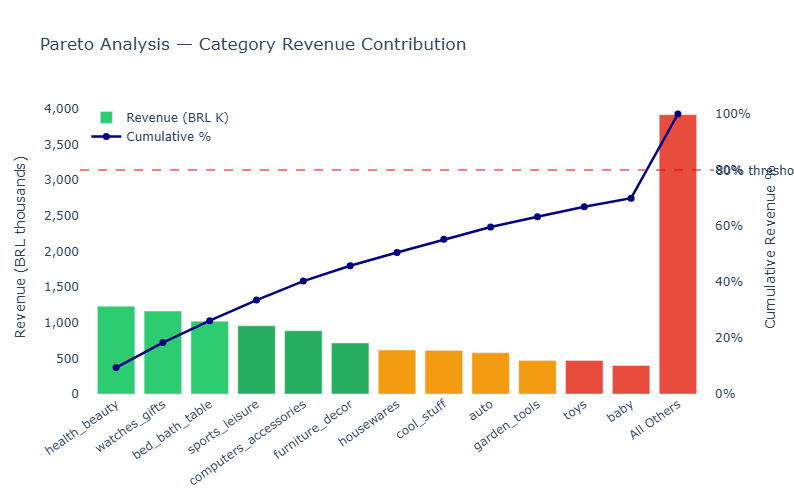


80% of revenue reached at category #13: All Others
Focus these 13 categories for maximum revenue impact


In [8]:
waterfall_df['cumulative_pct'] = (
    waterfall_df['revenue'].cumsum() /
    waterfall_df['revenue'].sum() * 100
).round(2)

fig = go.Figure()

# Bars
fig.add_trace(go.Bar(
    x    = waterfall_df['category'],
    y    = waterfall_df['revenue'] / 1e3,
    name = 'Revenue (BRL K)',
    marker_color = ['#2ecc71' if i < 3 else
                    '#27ae60' if i < 6 else
                    '#f39c12' if i < 10 else
                    '#e74c3c'
                    for i in range(len(waterfall_df))],
    yaxis= 'y1'
))

# Cumulative line
fig.add_trace(go.Scatter(
    x    = waterfall_df['category'],
    y    = waterfall_df['cumulative_pct'],
    name = 'Cumulative %',
    mode = 'lines+markers',
    line = dict(color='navy', width=2.5),
    marker = dict(size=7),
    yaxis= 'y2'
))

# 80% reference line
fig.add_hline(y=80, line_dash='dash',
              line_color='red', opacity=0.5,
              annotation_text='80% threshold',
              annotation_position='right',
              yref='y2')

fig.update_layout(
    title  = 'Pareto Analysis — Category Revenue Contribution',
    xaxis  = dict(tickangle=-35),
    yaxis  = dict(title='Revenue (BRL thousands)', tickformat=',.0f'),
    yaxis2 = dict(title='Cumulative Revenue %',
                  overlaying='y', side='right',
                  range=[0, 105],
                  ticksuffix='%'),
    height        = 500,
    plot_bgcolor  = 'white',
    paper_bgcolor = 'white',
    legend        = dict(x=0.01, y=0.99)
)

fig.show()

threshold_row = waterfall_df[waterfall_df['cumulative_pct'] >= 80].iloc[0]
idx_80        = waterfall_df[waterfall_df['cumulative_pct'] >= 80].index[0]
print(f"\n80% of revenue reached at category #{idx_80+1}: "
      f"{threshold_row['category']}")
print(f"Focus these {idx_80+1} categories for maximum revenue impact")

In [9]:
# Monthly revenue — clean 2017-2018 window
monthly = (merged
    .groupby(merged['order_purchase_timestamp']
             .dt.to_period('M'))['revenue']
    .sum()
    .reset_index()
)
monthly.columns = ['month', 'actual_revenue']
monthly = monthly[
    monthly['month'].astype(str).between('2017-01','2018-08')
].copy()
monthly['month_str'] = monthly['month'].astype(str)
monthly = monthly.reset_index(drop=True)

# Simple 3-month rolling average forecast
monthly['forecast'] = (monthly['actual_revenue']
                        .shift(1)
                        .rolling(3, min_periods=1)
                        .mean()
                        .round(2))

# Forecast error
monthly['variance']     = (monthly['actual_revenue'] -
                            monthly['forecast']).round(2)
monthly['variance_pct'] = (monthly['variance'] /
                            monthly['forecast'] * 100).round(2)

# Category monthly breakdown for slicer
cat_monthly = (merged
    .groupby([merged['order_purchase_timestamp'].dt.to_period('M'),
              'product_category_name_english'])['revenue']
    .sum()
    .reset_index()
)
cat_monthly.columns      = ['month','category','revenue']
cat_monthly['month_str'] = cat_monthly['month'].astype(str)
cat_monthly = cat_monthly[
    cat_monthly['month_str'].between('2017-01','2018-08')
]

# State monthly breakdown for slicer
state_monthly = (merged
    .groupby([merged['order_purchase_timestamp'].dt.to_period('M'),
              'customer_state'])['revenue']
    .sum()
    .reset_index()
)
state_monthly.columns      = ['month','state','revenue']
state_monthly['month_str'] = state_monthly['month'].astype(str)
state_monthly = state_monthly[
    state_monthly['month_str'].between('2017-01','2018-08')
]

print("Monthly data + forecast built ✓")
print(monthly[['month_str','actual_revenue',
               'forecast','variance_pct']].to_string(index=False))

Monthly data + forecast built ✓
month_str  actual_revenue  forecast  variance_pct
  2017-01       111798.36       NaN           NaN
  2017-02       234223.40 111798.36        109.51
  2017-03       359198.85 173010.88        107.62
  2017-04       340669.68 235073.54         44.92
  2017-05       489338.25 311363.98         57.16
  2017-06       421923.37 396402.26          6.44
  2017-07       481604.52 417310.43         15.41
  2017-08       554699.70 464288.71         19.47
  2017-09       607399.67 486075.86         24.96
  2017-10       648247.65 547901.30         18.31
  2017-11       987765.37 603449.01         63.69
  2017-12       726033.19 747804.23         -2.91
  2018-01       924645.00 787348.74         17.44
  2018-02       826437.13 879481.19         -6.03
  2018-03       953356.25 825705.11         15.46
  2018-04       973534.09 901479.46          7.99
  2018-05       977544.69 917775.82          6.51
  2018-06       856077.86 968145.01        -11.58
  2018-07       86

In [10]:
# ── Widget definitions ─────────────────────────────────────
top_cats   = (cat_monthly.groupby('category')['revenue']
              .sum().nlargest(15).index.tolist())
all_states = sorted(merged['customer_state'].dropna().unique().tolist())

# Slicer 1 — filter type
filter_type_widget = widgets.ToggleButtons(
    options     = ['All Brazil', 'By Category', 'By State'],
    description = 'View :',
    style       = {'description_width': 'initial'},
    button_style= 'info'
)

# Slicer 2 — category selector
category_widget = widgets.Dropdown(
    options     = top_cats,
    value       = top_cats[0],
    description = 'Category:',
    style       = {'description_width': 'initial'},
    layout      = widgets.Layout(width='320px')
)

# Slicer 3 — state selector
state_widget = widgets.Dropdown(
    options     = all_states,
    value       = 'SP',
    description = 'State:',
    style       = {'description_width': 'initial'},
    layout      = widgets.Layout(width='200px')
)

# Slicer 4 — show forecast toggle
forecast_widget = widgets.Checkbox(
    value       = True,
    description = 'Show Forecast Line',
    style       = {'description_width': 'initial'}
)

# Slicer 5 — year range
year_widget = widgets.SelectionRangeSlider(
    options     = monthly['month_str'].tolist(),
    index       = (0, len(monthly)-1),
    description = 'Period:',
    style       = {'description_width': 'initial'},
    layout      = widgets.Layout(width='500px')
)

out = Output()

def update_chart(filter_type, category, state,
                 show_forecast, year_range):
    out.clear_output(wait=True)

    start, end = year_range

    # ── Filter data based on slicer ───────────────────────
    if filter_type == 'All Brazil':
        df = monthly[monthly['month_str'].between(start, end)].copy()
        title_str = 'All Brazil'

    elif filter_type == 'By Category':
        df = (cat_monthly[
                (cat_monthly['category']   == category) &
                (cat_monthly['month_str'].between(start, end))
              ][['month_str','revenue']]
              .rename(columns={'revenue':'actual_revenue'})
              .copy())
        df['forecast'] = (df['actual_revenue']
                          .shift(1)
                          .rolling(3, min_periods=1)
                          .mean()
                          .round(2))
        title_str = f'Category: {category}'

    else:
        df = (state_monthly[
                (state_monthly['state']    == state) &
                (state_monthly['month_str'].between(start, end))
              ][['month_str','revenue']]
              .rename(columns={'revenue':'actual_revenue'})
              .copy())
        df['forecast'] = (df['actual_revenue']
                          .shift(1)
                          .rolling(3, min_periods=1)
                          .mean()
                          .round(2))
        title_str = f'State: {state}'

    df = df.reset_index(drop=True)

    # ── Build Plotly chart ────────────────────────────────
    fig = go.Figure()

    # Actual revenue bars
    fig.add_trace(go.Bar(
        x            = df['month_str'],
        y            = df['actual_revenue'],
        name         = 'Actual Revenue',
        marker_color = '#3498db',
        opacity      = 0.75,
        hovertemplate= ('<b>%{x}</b><br>'
                        'Actual: BRL %{y:,.0f}<extra></extra>')
    ))

    # Actual revenue line
    fig.add_trace(go.Scatter(
        x          = df['month_str'],
        y          = df['actual_revenue'],
        name       = 'Actual Trend',
        mode       = 'lines+markers',
        line       = dict(color='#2980b9', width=2.5),
        marker     = dict(size=7),
        hovertemplate = ('<b>%{x}</b><br>'
                         'Revenue: BRL %{y:,.0f}<extra></extra>')
    ))

    # Forecast line
    if show_forecast and 'forecast' in df.columns:
        fig.add_trace(go.Scatter(
            x          = df['month_str'],
            y          = df['forecast'],
            name       = '3-Month Rolling Forecast',
            mode       = 'lines+markers',
            line       = dict(color='#e74c3c', width=2,
                              dash='dash'),
            marker     = dict(size=6, symbol='diamond'),
            hovertemplate = ('<b>%{x}</b><br>'
                             'Forecast: BRL %{y:,.0f}<extra></extra>')
        ))

        # Variance shading
        fig.add_trace(go.Scatter(
            x          = (df['month_str'].tolist() +
                          df['month_str'].tolist()[::-1]),
            y          = (df['actual_revenue'].tolist() +
                          df['forecast'].tolist()[::-1]),
            fill       = 'toself',
            fillcolor  = 'rgba(231,76,60,0.08)',
            line       = dict(color='rgba(255,255,255,0)'),
            showlegend = True,
            name       = 'Actual vs Forecast Gap'
        ))

    # Annotations for peak and trough
    if len(df) > 0 and 'actual_revenue' in df.columns:
        peak_idx  = df['actual_revenue'].idxmax()
        peak_val  = df['actual_revenue'].max()
        peak_mon  = df.loc[peak_idx, 'month_str']

        fig.add_annotation(
            x          = peak_mon,
            y          = peak_val,
            text       = f"Peak<br>BRL {peak_val/1e3:.0f}K",
            showarrow  = True,
            arrowhead  = 2,
            arrowcolor = '#27ae60',
            font       = dict(color='#27ae60', size=10),
            bgcolor    = 'white',
            bordercolor= '#27ae60'
        )

    total_rev = df['actual_revenue'].sum()
    avg_rev   = df['actual_revenue'].mean()

    fig.update_layout(
        title      = dict(
            text   = (f'Sales vs Forecast — {title_str}<br>'
                      f'<sup>Total: BRL {total_rev:,.0f}  |  '
                      f'Monthly Avg: BRL {avg_rev:,.0f}</sup>'),
            font   = dict(size=14)
        ),
        xaxis      = dict(tickangle=-35, title='Month'),
        yaxis      = dict(title     = 'Revenue (BRL)',
                          tickformat= ',.0f'),
        height     = 480,
        plot_bgcolor  = 'white',
        paper_bgcolor = 'white',
        legend        = dict(orientation='h',
                             yanchor='bottom', y=1.02,
                             xanchor='right', x=1),
        bargap     = 0.3
    )

    with out:
        fig.show()

# ── Wire widgets to chart function ─────────────────────────
widgets.interactive_output(
    update_chart,
    {
        'filter_type'   : filter_type_widget,
        'category'      : category_widget,
        'state'         : state_widget,
        'show_forecast' : forecast_widget,
        'year_range'    : year_widget
    }
)

# ── Display layout ─────────────────────────────────────────
controls_row1 = widgets.HBox([filter_type_widget, forecast_widget])
controls_row2 = widgets.HBox([category_widget, state_widget])
controls_row3 = widgets.HBox([year_widget])

display(widgets.VBox([
    controls_row1,
    controls_row2,
    controls_row3,
    out
]))

In [11]:
accuracy = monthly.copy()
accuracy['abs_error']     = accuracy['variance'].abs()
accuracy['within_10pct']  = (accuracy['variance_pct'].abs() <= 10)
accuracy['within_20pct']  = (accuracy['variance_pct'].abs() <= 20)

print("=== Forecast Accuracy Report ===\n")
print(accuracy[['month_str','actual_revenue',
                'forecast','variance','variance_pct'
                ]].dropna().to_string(index=False))

valid = accuracy.dropna(subset=['forecast'])
print(f"\nMAE (Mean Abs Error)   : BRL {valid['abs_error'].mean():,.0f}")
print(f"Months within 10%     : "
      f"{valid['within_10pct'].sum()} / {len(valid)}")
print(f"Months within 20%     : "
      f"{valid['within_20pct'].sum()} / {len(valid)}")
print(f"\nNov 2017 was the hardest to forecast — "
      f"Black Friday spike was {accuracy[accuracy['month_str']=='2017-11']['variance_pct'].values[0]:.1f}% "
      f"above forecast")

=== Forecast Accuracy Report ===

month_str  actual_revenue  forecast   variance  variance_pct
  2017-02       234223.40 111798.36  122425.04        109.51
  2017-03       359198.85 173010.88  186187.97        107.62
  2017-04       340669.68 235073.54  105596.14         44.92
  2017-05       489338.25 311363.98  177974.27         57.16
  2017-06       421923.37 396402.26   25521.11          6.44
  2017-07       481604.52 417310.43   64294.09         15.41
  2017-08       554699.70 464288.71   90410.99         19.47
  2017-09       607399.67 486075.86  121323.81         24.96
  2017-10       648247.65 547901.30  100346.35         18.31
  2017-11       987765.37 603449.01  384316.36         63.69
  2017-12       726033.19 747804.23  -21771.04         -2.91
  2018-01       924645.00 787348.74  137296.26         17.44
  2018-02       826437.13 879481.19  -53044.06         -6.03
  2018-03       953356.25 825705.11  127651.14         15.46
  2018-04       973534.09 901479.46   72054.63     